In [31]:
# import libraires
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# read csv file using read_csv 
df = pd.read_csv(r"C:\Turki-altayeb\الدورات\هاش بلس\معسكر تحليل البيانات\Day 6\cleaned_data.xls")

### استكشاف البيانات \ Data Explor

In [33]:
# Display first 5 rows 
#روئية الصفوف ال 10 الاولى 
df.head(15)

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level
0,INV-10001,Mecca,Recorded Subscription,532.0,266,266,2023-03-17,4.1,Laravel & PHP,Advanced
1,INV-10002,Jeddah,Recorded Subscription,289.0,0,289,2023-03-15,4.5,Laravel & PHP,Beginner
2,INV-10003,Dammam,Recorded Subscription,474.0,94,380,2023-03-15,4.4,UI/UX Design,Intermediate
3,INV-10004,Khobar,Recorded Subscription,265.0,0,265,2023-03-15,4.7,UI/UX Design,Beginner
4,INV-10005,Mecca,Recorded Subscription,228.0,45,183,2023-03-22,4.6,React & Next.js,Beginner
5,INV-10006,Riyadh,Live Bootcamp,1542.0,0,1542,1900-01-01,4.5,Flutter Development,Beginner
6,INV-10007,Khobar,Recorded Subscription,269.0,134,135,2023-02-10,4.5,Flutter Development,Beginner
7,INV-10008,Tabuk,Recorded Subscription,211.0,42,169,2023-03-15,4.7,Data Analysis,Beginner
8,INV-10009,Riyadh,Recorded Subscription,397.0,0,397,2023-03-15,4.4,Flutter Development,Intermediate
9,INV-10010,Jeddah,Recorded Subscription,292.0,0,292,2023-03-08,4.6,Python Basics,Beginner



### مبدئيا البيانات مو نظيفة تحتاج تنظيف في نقص في عمود التقييم والتواريخ مو موحدة  واحتاج تفاصيل الكورس بدل ماهو اسم اكورس واللفل فعمود واحد اقسمها افضل واسهل عشا الترتيب

In [34]:
# (Row , Column )
df.shape

(5002, 10)

In [35]:
# incpect about the data ( columns , null values , data types)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5002 entries, 0 to 5001
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Invoice_ID       5002 non-null   object 
 1   City             5002 non-null   object 
 2   Course_Type      5002 non-null   object 
 3   Price            5002 non-null   float64
 4   Discount         5002 non-null   int64  
 5   Final_Total      5002 non-null   int64  
 6   Enrollment_Date  5002 non-null   object 
 7   Rating           5002 non-null   float64
 8   Course_Name      5002 non-null   object 
 9   Level            5002 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 390.9+ KB


In [36]:
# calculate the overall type values ( movies , TV shows)
type_counts = df["Course_Type"].value_counts()
type_counts

Course_Type
Recorded Subscription    4020
Live Bootcamp             980
lIVE bOOTCAMP               1
rECORDED sUBSCRIPTION       1
Name: count, dtype: int64

In [37]:
df.groupby("City")["Course_Type"].count().sort_values(ascending=False).head(10)

City
Riyadh    938
Jeddah    860
Dammam    775
Medina    634
Khobar    627
Mecca     600
Tabuk     568
Name: Course_Type, dtype: int64

<Axes: xlabel='Course_Type'>

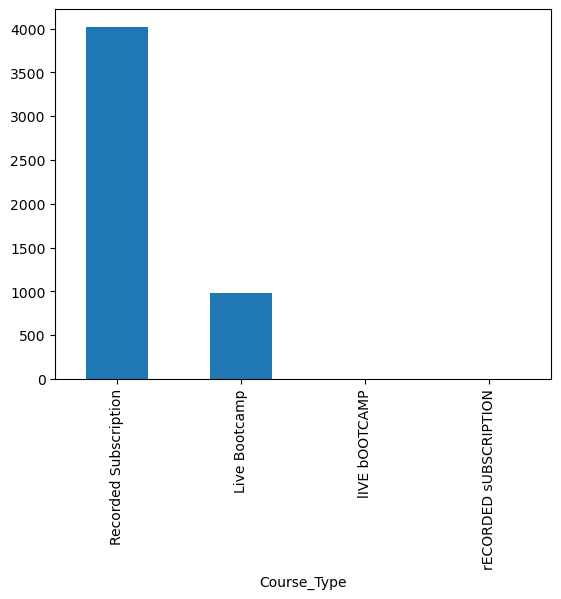

In [38]:
type_counts.plot(kind="bar")

### تنضيف البيانات \ Data Cleaning

In [39]:
# creating a copy from dataset
clean_df = df.copy()

In [40]:
#معرفة النواتج الفاضية 
clean_df.isnull().sum()

Invoice_ID         0
City               0
Course_Type        0
Price              0
Discount           0
Final_Total        0
Enrollment_Date    0
Rating             0
Course_Name        0
Level              0
dtype: int64

### في  50 صف فارغ في التقييم


مبدئيا البيانات مو نظيفة تحتاج تنظيف في نقص في عمود التقييم والتواريخ مو موحدة  واحتاج تفاصيل الكورس بدل ماهو اسم اكورس واللفل فعمود واحد اقسمها افضل واسهل عشا الترتيب

In [41]:
# فحص اذا في تكرارات 
clean_df.duplicated().sum()
#لايوجد تكرارات

np.int64(0)

### Data processing \ معالجة البيانات 

In [42]:
# Course_Details \ فصل عمود ال 
clean_df["Course_Details"] = clean_df["Course_Details"].str.split("|")
clean_df = clean_df.explode("Level")

KeyError: 'Course_Details'

In [ ]:
clean_df.head(20)

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level
0,INV-10001,Mecca,Recorded Subscription,532,266,266,3/17/2023,4.1,Laravel & PHP,Advanced
1,INV-10002,Jeddah,Recorded Subscription,289,0,289,"2023, March 15",4.5,Laravel & PHP,Beginner
2,INV-10003,Dammam,Recorded Subscription,474,94,380,"2023, March 15",4.4,UI/UX Design,Intermediate
3,INV-10004,Khobar,Recorded Subscription,265,0,265,"2023, March 15",4.7,UI/UX Design,Beginner
4,INV-10005,Mecca,Recorded Subscription,228,45,183,22-03-2023,4.6,React & Next.js,Beginner
5,INV-10006,Riyadh,Live Bootcamp,1542,0,1542,1/1/1900,4.5,Flutter Development,Beginner
6,INV-10007,Khobar,Recorded Subscription,269,134,135,10/2/2023,4.5,Flutter Development,Beginner
7,INV-10008,Tabuk,Recorded Subscription,211,42,169,"2023, March 15",4.7,Data Analysis,Beginner
8,INV-10009,Riyadh,Recorded Subscription,397,0,397,"2023, March 15",?,Flutter Development,Intermediate
9,INV-10010,Jeddah,Recorded Subscription,292,0,292,8/3/2023,4.6,Python Basics,Beginner


In [ ]:
#تعويض النقص في الريتينق
clean_df['Rating'] = clean_df['Rating'].replace('?', pd.NA)
clean_df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
clean_df['Rating'] = clean_df['Rating'].fillna(clean_df['Rating'].mean())

In [ ]:
# تعديل الى بس فاصلة واحدة \ Rating 
clean_df["Rating"] = clean_df["Rating"].astype(float).round(1)

In [ ]:
#تحويل السعر الى float
clean_df["Price"] = clean_df["Price"].replace('[^0-9.]', '', regex=True)
clean_df["Price"] = clean_df["Price"].astype(float)

In [ ]:
#معرفة صيغ التواريخ 
clean_df["Enrollment_Date"].unique()[:20]

array(['3/17/2023', '2023, March 15', '22-03-2023', '1/1/1900',
       '10/2/2023', '8/3/2023', '13-12-2023', '10/17/2023', '12/16/2023',
       '20-02-2023', '14-07-2023', '19-07-2023', '21-03-2023', '9/7/2023',
       '10/1/2023', '10/13/2023', '8/11/2023', '1/5/2023', '10/24/2023',
       '1/25/2024'], dtype=object)

In [ ]:
#توحيد التاريخ 
# تحويل التاريخ (يدعم كل التنسيقات)
clean_df["Enrollment_Date"] = pd.to_datetime(clean_df["Enrollment_Date"], errors="coerce", format="mixed", dayfirst=True)
# أي قيمة فشلت → نحولها لقيمة افتراضية 
clean_df["Enrollment_Date"] = clean_df["Enrollment_Date"].fillna(pd.Timestamp("2000-01-01"))
# توحيد الشكل
clean_df["Enrollment_Date"] = clean_df["Enrollment_Date"].dt.strftime("%Y-%m-%d")

In [ ]:
clean_df.head(20)

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level
0,INV-10001,Mecca,Recorded Subscription,532.0,266,266,2023-03-17,4.1,Laravel & PHP,Advanced
1,INV-10002,Jeddah,Recorded Subscription,289.0,0,289,2023-03-15,4.5,Laravel & PHP,Beginner
2,INV-10003,Dammam,Recorded Subscription,474.0,94,380,2023-03-15,4.4,UI/UX Design,Intermediate
3,INV-10004,Khobar,Recorded Subscription,265.0,0,265,2023-03-15,4.7,UI/UX Design,Beginner
4,INV-10005,Mecca,Recorded Subscription,228.0,45,183,2023-03-22,4.6,React & Next.js,Beginner
5,INV-10006,Riyadh,Live Bootcamp,1542.0,0,1542,1900-01-01,4.5,Flutter Development,Beginner
6,INV-10007,Khobar,Recorded Subscription,269.0,134,135,2023-02-10,4.5,Flutter Development,Beginner
7,INV-10008,Tabuk,Recorded Subscription,211.0,42,169,2023-03-15,4.7,Data Analysis,Beginner
8,INV-10009,Riyadh,Recorded Subscription,397.0,0,397,2023-03-15,4.4,Flutter Development,Intermediate
9,INV-10010,Jeddah,Recorded Subscription,292.0,0,292,2023-03-08,4.6,Python Basics,Beginner


### Data Analysis \ تحليل البيانات

In [ ]:
clean_df["Course_Name"].value_counts()

Course_Name
Python Basics          871
UI/UX Design           845
Laravel & PHP          839
React & Next.js        830
Flutter Development    827
Data Analysis          790
Name: count, dtype: int64

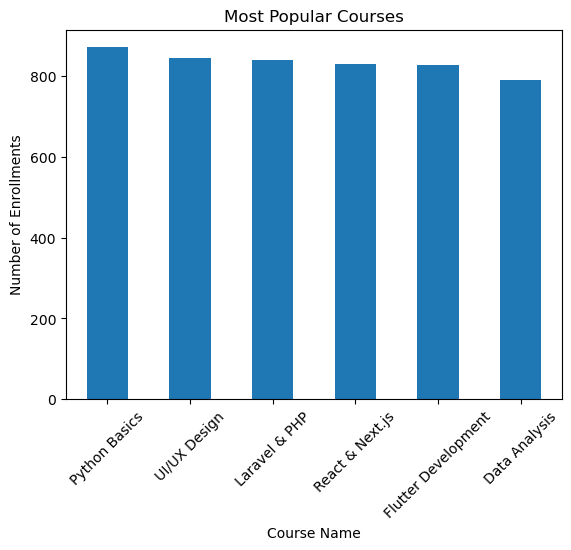

In [ ]:
import matplotlib.pyplot as plt

clean_df["Course_Name"].value_counts().plot(kind="bar")
plt.title("Most Popular Courses")
plt.xlabel("Course Name")
plt.ylabel("Number of Enrollments")
plt.xticks(rotation=45)
plt.show()




In [ ]:
# Python Basics \ اكثر كورس عليه اقبال هو

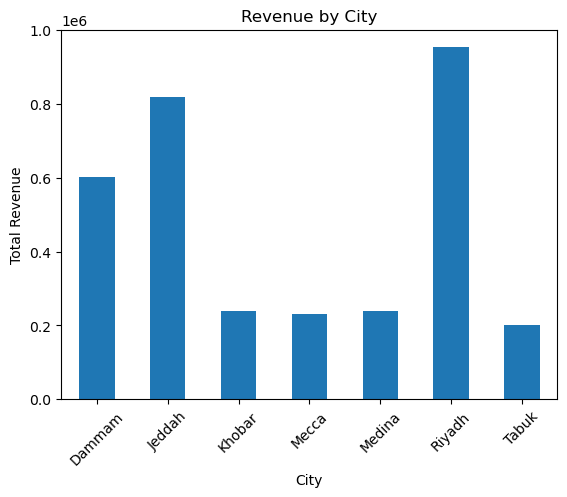

In [ ]:
#الإيرادات حسب المدينة
clean_df.groupby("City")["Final_Total"].sum().plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#متوسط التقييم لكل كورس
clean_df.groupby("Course_Name")["Rating"].mean().sort_values(ascending=False)

Course_Name
React & Next.js        4.390482
Laravel & PHP          4.385221
Flutter Development    4.381378
Python Basics          4.379334
Data Analysis          4.375696
UI/UX Design           4.375385
Name: Rating, dtype: float64

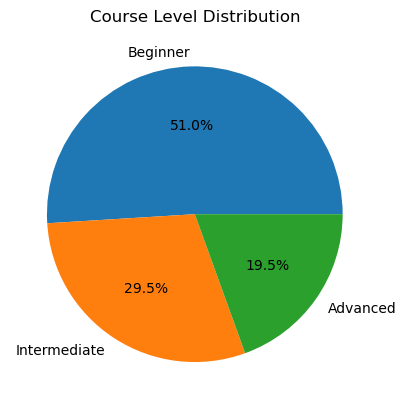

<Figure size 800x500 with 0 Axes>

In [ ]:
# نسب المستويات
clean_df["Level"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Course Level Distribution")
plt.ylabel("")
plt.show()


### الاستنتاجات:
### 1- الكورس الأكثر طلبًا هو (Python Basics)، وهذا يدل على أن المستخدمين مهتمين بمجال البرمجة ويمكن الاستثمار فيه أكثر عن طريق تطوير مهاراتهم في البرمجة .
### 2- مدينة (الرياض) تحقق أعلى إيرادات، مما يشير إلى أنها السوق الأقوى ويجب التركيز عليها في الحملات التسويقية
### 3- أغلب المستخدمين من مستوى Beginner، مما يعني أن المستهدفين هم المبتدئين بشكل كبير.

# Day 6 Task6:

In [ ]:
clean_df.head()

,Invoice_ID,City,Course_Type,Price,Discount,Final_Total,Enrollment_Date,Rating,Course_Name,Level
0,INV-10001,Mecca,Recorded Subscription,532.0,266,266,2023-03-17,4.1,Laravel & PHP,Advanced
1,INV-10002,Jeddah,Recorded Subscription,289.0,0,289,2023-03-15,4.5,Laravel & PHP,Beginner
2,INV-10003,Dammam,Recorded Subscription,474.0,94,380,2023-03-15,4.4,UI/UX Design,Intermediate
3,INV-10004,Khobar,Recorded Subscription,265.0,0,265,2023-03-15,4.7,UI/UX Design,Beginner
4,INV-10005,Mecca,Recorded Subscription,228.0,45,183,2023-03-22,4.6,React & Next.js,Beginner


In [ ]:
#عرض أعمدة (اسم الدورة، السعر، والمدينة) لمبيعات مدينة جدة فقط 
clean_df.loc[clean_df["City"] == "Jeddah", ["Course_Name" , "Price" , "City"]].head(10)

,Course_Name,Price,City
1,Laravel & PHP,289.0,Jeddah
9,Python Basics,292.0,Jeddah
10,Python Basics,210.0,Jeddah
11,React & Next.js,328.0,Jeddah
17,Laravel & PHP,299.0,Jeddah
18,Laravel & PHP,2795.0,Jeddah
24,Python Basics,221.0,Jeddah
28,UI/UX Design,318.0,Jeddah
33,Python Basics,314.0,Jeddah
41,UI/UX Design,276.0,Jeddah


In [46]:
# إنشاء عمود  باسم حالة الخصم يكتب خصم اذا كان الخصم اكثر من 0 و السعر كامل اذا كان الخصم اقل من 0
clean_df["Discount_Status"] = np.where(
    clean_df["Discount"] > 0,
    "Discounted","Full Price"
)
#التحقق من الشرط
clean_df[["Course_Name" , "Price" ,"Discount","Discount_Status" , "City"]].sample(10)


,Course_Name,Price,Discount,Discount_Status,City
1227,Data Analysis,2210.0,0,Full Price,Jeddah
410,Laravel & PHP,2864.0,0,Full Price,Dammam
3839,Data Analysis,1666.0,166,Discounted,Riyadh
2130,React & Next.js,573.0,114,Discounted,Tabuk
3526,UI/UX Design,227.0,45,Discounted,Tabuk
371,Laravel & PHP,215.0,43,Discounted,Tabuk
4056,Flutter Development,390.0,0,Full Price,Khobar
3852,React & Next.js,315.0,63,Discounted,Jeddah
1304,Laravel & PHP,342.0,68,Discounted,Jeddah
207,Python Basics,260.0,52,Discounted,Medina


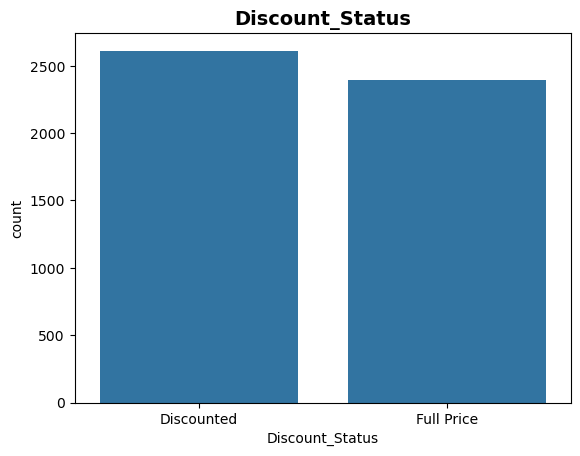

In [90]:
#معرفة الخصومات
sns.countplot(data = clean_df , x = "Discount_Status")
plt.title("Discount_Status" , fontsize=14 , fontweight='bold')
plt.show()

In [54]:
#انشاء عمود يكتب "تقييم  عالي" إذا كان التقييم 4.5 وفوق، و "عادي" إذا كان أقل.
def New_colmun(Rating):
    if Rating >= 4.5:
        return "High Rating"
    else:
        return "Normal"
clean_df["Rating_Status"] =  clean_df["Rating"].apply(New_colmun) #بيكون اسم العمود Rating_Status
#التحقق من الشرط 
clean_df[["Course_Name","Price","Discount","Rating","Rating_Status","City"]].sample(10)

,Course_Name,Price,Discount,Rating,Rating_Status,City
1486,UI/UX Design,633.0,316,4.6,High Rating,Khobar
285,Flutter Development,581.0,0,3.9,Normal,Khobar
4591,React & Next.js,256.0,51,4.6,High Rating,Khobar
1436,Python Basics,613.0,0,4.0,Normal,Dammam
4129,UI/UX Design,420.0,0,4.5,High Rating,Dammam
1077,Laravel & PHP,632.0,126,4.2,Normal,Dammam
4119,Flutter Development,1692.0,0,4.8,High Rating,Dammam
4084,Laravel & PHP,472.0,94,4.4,Normal,Riyadh
3923,Laravel & PHP,251.0,50,4.8,High Rating,Dammam
1215,Python Basics,376.0,0,3.9,Normal,Jeddah


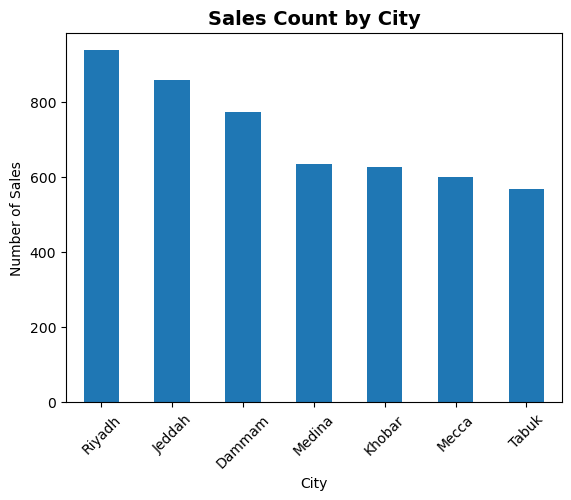

In [88]:
#عدد المبيعات في كل مدينة
clean_df["City"].value_counts().plot(kind="bar")
plt.title("Sales Count by City",fontsize=14 , fontweight='bold')
plt.xlabel("City")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)
plt.show()

C:\Users\Mobily\AppData\Local\Temp\ipykernel_26104\1592878443.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=clean_df, x="Discount_Status", palette="Set2")


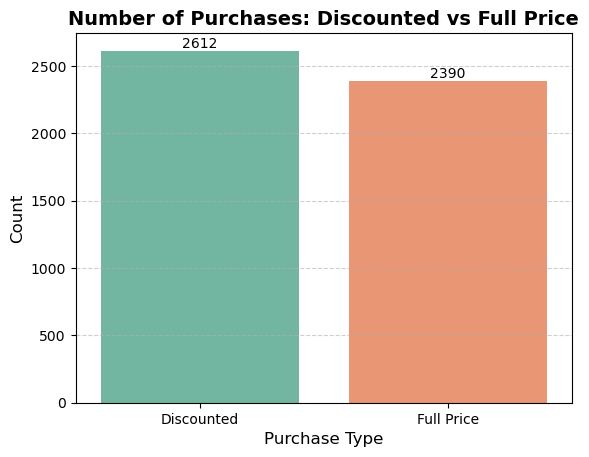

In [86]:
#رسم بياني  يوضح الفرق بين عدد اللي اشتروا بخصم واللي اشتروا بالسعر الكامل  
ax = sns.countplot(data=clean_df, x="Discount_Status", palette="Set2")

# إضافة الأرقام فوق الأعمدة
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Number of Purchases: Discounted vs Full Price", fontsize=14 , fontweight='bold')
plt.xlabel("Purchase Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### الخصومات تزيد عدد المبيعات
### The count plot shows that discounted purchases are higher than full-price purchases, indicating that discounts have a significant positive impact on customer buying behavior.

In [83]:
#اعلى كورس مبيعا
top_courses = clean_df["Course_Name"].value_counts().head(5)
top_courses

Course_Name
Python Basics          871
UI/UX Design           845
Laravel & PHP          839
React & Next.js        830
Flutter Development    827
Name: count, dtype: int64

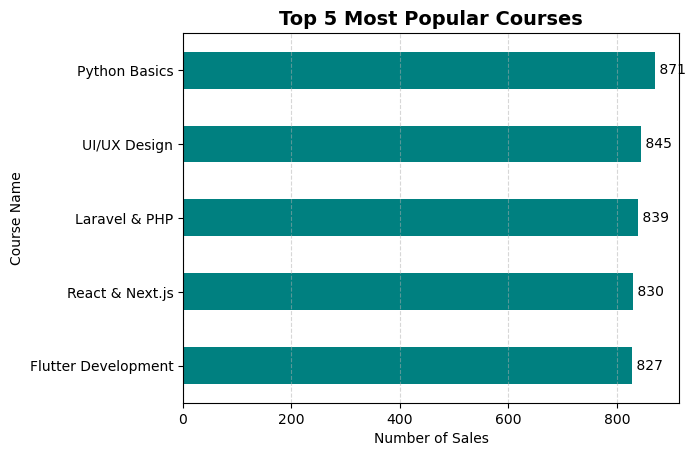

In [ ]:
ax = top_courses.sort_values().plot(kind="barh", color="teal")

for i, v in enumerate(top_courses.sort_values()):
    ax.text(v, i, f" {v}", va='center')

plt.title("Top 5 Most Popular Courses", fontsize=14, fontweight='bold')
plt.xlabel("Number of Sales")
plt.ylabel("Course Name")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# من خلال التحليل تبيّن أن:

# أعلى المدن مبيعًا هي الرياض تليها جدة
# معظم العملاء يشترون بخصم
# الخصومات تؤدي إلى زيادة عدد المبيعات مما يدل على تأثيرها الإيجابي على قرارات الشراء
# Python Basics \ تُعد  من أكثر الدورات طلبًا حيث سجلت أعلى عدد من المبيعات مقارنة ببقية الدورات
# وهذا يدل على وجود طلب مرتفع على المهارات الأساسية في البرمجة